In [2]:
# ==============================================================================
# Development and Internal Validation of Clinical Prediction Models for MASLD
# Amol Cohort Study (AmolCS) - 7-Year Risk Prediction
# Coded By Masoud Imani
# Email: Masoudimani7@gmail.com
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from scipy.stats import norm

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, brier_score_loss, average_precision_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from tableone import TableOne
import shap

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not found. Pipeline will skip XGBoost evaluation.")

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x  

import warnings
warnings.filterwarnings('ignore')

# Global Reproducibility Settings
RANDOM_STATE = 42
N_SPLITS = 5
THRESHOLDS = np.arange(0.10, 0.52, 0.02)
OPTIMIZE_METRIC = "youden"

# ==============================================================================
# PHASE 1: COHORT CONSTRUCTION & ATTRITION ANALYSIS
# ==============================================================================
print("Loading data...")
df = pd.read_csv("Updated_MASLD.csv")


def yn_to01(s):
    return s.astype('string').str.strip().str.lower().map(
        {'yes': 1, 'y': 1, '1': 1, 'true': 1, 'no': 0, 'n': 0, '0': 0, 'false': 0}
    ).astype('Int64')

# 1. Feature Engineering
bp_cols = ['sbp1_1', 'sbp1_2', 'dbp1_1', 'dbp1_2']
df[bp_cols] = df[bp_cols].apply(pd.to_numeric, errors='coerce')
df['sbp_mean'] = df[['sbp1_1', 'sbp1_2']].mean(axis=1)
df['dbp_mean'] = df[['dbp1_1', 'dbp1_2']].mean(axis=1)

df['measureweight_1'] = pd.to_numeric(df['measureweight_1'], errors='coerce')
df['measurelength_1'] = pd.to_numeric(df['measurelength_1'], errors='coerce')
h_m = df['measurelength_1'] / 100.0
valid = (df['measureweight_1'] > 0) & (h_m > 0)
df['BMI (kg/m^2)'] = np.where(valid, df['measureweight_1'] / (h_m ** 2), np.nan)

# 2. Target Definition & Follow-up Tracking
df['m_masld_1_clean'] = yn_to01(df['m_masld_1'])
df['m_masld_2_clean'] = yn_to01(df['m_masld_2'])
inc_raw = df['m_masld_incidence'].astype('string').str.strip().str.lower()
df['inc_clean'] = inc_raw.map({'incidence': 1, 'negative': 0, 'regress': pd.NA}).astype('Int64')

df['target'] = df['inc_clean'].copy()
need_fill = df['target'].isna() & df['m_masld_2_clean'].notna()
df.loc[need_fill, 'target'] = df.loc[need_fill, 'm_masld_2_clean']

mask_has_outcome = df['target'].notna() & (inc_raw != 'regress')

# 3. SMD for Loss to Follow-up 
print("\n--- SMD for Loss to Follow-up (Retained vs Lost) ---")
print(f"Retained: {mask_has_outcome.sum()} | Lost: {(~mask_has_outcome).sum()}")
for var in ['age_m', 'BMI (kg/m^2)', 'alt_1', 'ast_1', 'tg_1', 'sbp_mean']:
    df[var] = pd.to_numeric(df[var], errors='coerce')
    mean1, std1 = df.loc[mask_has_outcome, var].mean(), df.loc[mask_has_outcome, var].std()
    mean2, std2 = df.loc[~mask_has_outcome, var].mean(), df.loc[~mask_has_outcome, var].std()
    smd = np.abs(mean1 - mean2) / np.sqrt((std1**2 + std2**2) / 2)
    print(f"{var:15s} SMD = {smd:.3f}")

# 4. Exclusions & Sensitivity Analysis
df_step1 = df[mask_has_outcome].copy()
df_step2 = df_step1[df_step1['m_masld_1_clean'] == 0].copy()

df_step2['m_sld_1_clean'] = yn_to01(df_step2['m_sld_1'])
mask_isolated_steatosis = df_step2['m_sld_1_clean'] == 1
df_step3 = df_step2[~mask_isolated_steatosis].copy()
print(f"\nDropped {mask_isolated_steatosis.sum()} patients with isolated baseline steatosis.")

mask_hepatitis = df_step3[['m_hbsag_1', 'm_hcvab_1']].eq('Yes').any(axis=1)
df_step4 = df_step3[~mask_hepatitis].copy()

df_step4['m_cirrhosis_1'] = pd.to_numeric(df_step4['m_cirrhosis_1'], errors='coerce')
df_final = df_step4[df_step4['m_cirrhosis_1'] != 1].copy()

print(f"---> FINAL AT-RISK COHORT SIZE: {len(df_final)}")

# 5. Final Feature Matrix Preparation
model_vars = [
    'alt_1', 'ast_1', 'tg_1', 'hdl_1', 'ldl_1', 'sex', 'age_m',
    'm_hbsab_1', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1',
    'm_t2dm_1', 'sbp_mean', 'dbp_mean', 'BMI (kg/m^2)'
]

X = df_final[model_vars].copy()
for c in X.columns:
    if X[c].dtype == "object" or X[c].dtype == "string":
        s = X[c].astype("string").str.strip().str.lower()
        if c.lower() == 'sex':
            s = s.replace({"m": "1", "male": "1", "f": "0", "female": "0"})
        else:
            s = s.replace({"yes": "1", "no": "0", "true": "1", "false": "0"})
        X[c] = pd.to_numeric(s, errors='coerce')

y = df_final['target'].astype(int).copy()

Loading data...

--- SMD for Loss to Follow-up (Retained vs Lost) ---
Retained: 3819 | Lost: 1575
age_m           SMD = 0.333
BMI (kg/m^2)    SMD = 0.079
alt_1           SMD = 0.097
ast_1           SMD = 0.029
tg_1            SMD = 0.045
sbp_mean        SMD = 0.098

Dropped 276 patients with isolated baseline steatosis.
---> FINAL AT-RISK COHORT SIZE: 2354


In [3]:
# ==============================================================================
# PHASE 2: BASELINE CHARACTERISTICS (TABLE 1)
# ==============================================================================
df_table1 = X.copy()
df_table1['Incident_MASLD'] = y.values
df_table1['Incident_MASLD'] = df_table1['Incident_MASLD'].map({0: 'No MASLD (Healthy)', 1: 'Developed MASLD'})

cat_cols = ['sex', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1', 'm_t2dm_1', 'm_hbsab_1']
for col in cat_cols:
    if col in df_table1.columns:
        if col == 'sex':
            df_table1[col] = df_table1[col].map({0.0: 'Female', 1.0: 'Male'})
        else:
            df_table1[col] = df_table1[col].map({0.0: 'No', 1.0: 'Yes'})

columns_to_summarize = ['age_m', 'BMI (kg/m^2)', 'sbp_mean', 'dbp_mean', 'alt_1', 'ast_1', 'tg_1', 'hdl_1', 'ldl_1'] + cat_cols
non_normal_variables = ['alt_1', 'ast_1', 'tg_1']

rename_dict = {
    'age_m': 'Age (years)', 'sex': 'Sex', 'BMI (kg/m^2)': 'Body Mass Index (kg/m²)',
    'sbp_mean': 'Systolic BP (mmHg)', 'dbp_mean': 'Diastolic BP (mmHg)',
    'alt_1': 'ALT (U/L)', 'ast_1': 'AST (U/L)', 'tg_1': 'Triglycerides (mg/dL)',
    'hdl_1': 'HDL Cholesterol (mg/dL)', 'ldl_1': 'LDL Cholesterol (mg/dL)',
    'm_smoke_1': 'Current Smoker', 'm_metsatp3_1': 'Metabolic Syndrome (ATP III)',
    'm_lipm_1': 'Dyslipidemia', 'm_htnm_1': 'Hypertension', 'm_t2dm_1': 'Type 2 Diabetes',
    'm_hbsab_1': 'HBsAb Positive'
}

df_table1 = df_table1.rename(columns=rename_dict)
updated_columns = [rename_dict.get(c, c) for c in columns_to_summarize]
updated_categorical = [rename_dict.get(c, c) for c in cat_cols]
updated_non_normal = [rename_dict.get(c, c) for c in non_normal_variables]

table1 = TableOne(
    data=df_table1, columns=updated_columns, categorical=updated_categorical,
    groupby='Incident_MASLD', nonnormal=updated_non_normal, pval=True, overall=True, missing=True 
)

print(table1.tabulate(tablefmt="github"))
table1.to_excel("Table1_Baseline_Characteristics.xlsx")

|                                       |        | Missing   | Overall           | Developed MASLD    | No MASLD (Healthy)   | P-Value   |
|---------------------------------------|--------|-----------|-------------------|--------------------|----------------------|-----------|
| n                                     |        |           | 2354              | 610                | 1744                 |           |
| Age (years), mean (SD)                |        | 6         | 42.7 (15.2)       | 42.9 (13.2)        | 42.6 (15.8)          | 0.649     |
| Body Mass Index (kg/m²), mean (SD)    |        | 0         | 25.7 (4.6)        | 28.2 (5.0)         | 24.8 (4.1)           | <0.001    |
| Systolic BP (mmHg), mean (SD)         |        | 1         | 112.4 (14.8)      | 115.1 (15.4)       | 111.5 (14.4)         | <0.001    |
| Diastolic BP (mmHg), mean (SD)        |        | 1         | 73.3 (12.2)       | 75.6 (12.4)        | 72.5 (12.1)          | <0.001    |
| ALT (U/L), median [Q1,Q3]

In [4]:
# ==============================================================================
# PHASE 3: MISSING DATA REPORT, CONVERGENCE LOGGING & STOCHASTIC IMPUTATION
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
print(f"Dataset Split -> Train set: {len(X_train)} | Test set: {len(X_test)}\n")

# 1. Missing Data Report 
print("--- Missing Data Report Before Imputation (Reviewer Requirement) ---")
missing_df = pd.DataFrame({
    'Missing Count': X.isnull().sum(),
    'Missing Percentage (%)': (X.isnull().mean() * 100)
})
missing_vars = missing_df[missing_df['Missing Count'] > 0].round(2)
if not missing_vars.empty:
    display(missing_vars)
else:
    print("No missing data found.")

# 2. Stochastic Multiple Imputation with Convergence Logging
print("\n--- Performing Stochastic MICE Imputation (Showing Convergence Logs) ---")
# verbose=2 proves mathematical convergence of the imputation 
imputer_base = IterativeImputer(max_iter=10, sample_posterior=True, random_state=RANDOM_STATE, initial_strategy='mean', verbose=2)

X_train_imp = pd.DataFrame(imputer_base.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp = pd.DataFrame(imputer_base.transform(X_test), columns=X_test.columns, index=X_test.index)

# Binarize categorical columns post-imputation
binary_cols = ['sex', 'm_hbsab_1', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1', 'm_t2dm_1']
for col in binary_cols:
    X_train_imp[col] = np.where(X_train_imp[col] > 0.5, 1.0, 0.0)
    X_test_imp[col] = np.where(X_test_imp[col] > 0.5, 1.0, 0.0)

# 3. Parsimonious Benchmark Model 
simple_vars = ['age_m', 'BMI (kg/m^2)', 'alt_1', 'tg_1']
simple_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, penalty='none', random_state=RANDOM_STATE))
])
simple_model.fit(X_train_imp[simple_vars], y_train)
y_prob_simple = simple_model.predict_proba(X_test_imp[simple_vars])[:, 1]
print(f"\nSimple Parsimonious Model (4 variables) ROC-AUC: {roc_auc_score(y_test, y_prob_simple):.3f}")

Dataset Split -> Train set: 1647 | Test set: 707

--- Missing Data Report Before Imputation (Reviewer Requirement) ---


,Missing Count,Missing Percentage (%)
alt_1,1,0.04
age_m,6,0.25
m_hbsab_1,115,4.89
m_smoke_1,294,12.49
sbp_mean,1,0.04
dbp_mean,1,0.04



--- Performing Stochastic MICE Imputation (Showing Convergence Logs) ---
[IterativeImputer] Completing matrix with shape (1647, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.37
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.72
[IterativeImputer] Ending imputation round 3/10, elapsed time 1.12
[IterativeImputer] Ending imputation round 4/10, elapsed time 1.46
[IterativeImputer] Ending imputation round 5/10, elapsed time 1.86
[IterativeImputer] Ending imputation round 6/10, elapsed time 2.15
[IterativeImputer] Ending imputation round 7/10, elapsed time 2.33
[IterativeImputer] Ending imputation round 8/10, elapsed time 2.54
[IterativeImputer] Ending imputation round 9/10, elapsed time 2.78
[IterativeImputer] Ending imputation round 10/10, elapsed time 3.32
[IterativeImputer] Completing matrix with shape (707, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.03
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.06
[Ite

--- Phase 1: RandomizedSearchCV Hyperparameter Tuning ---
Tuning LogisticRegression...
[IterativeImputer] Completing matrix with shape (1647, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.43
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.76
[IterativeImputer] Ending imputation round 3/10, elapsed time 1.14
[IterativeImputer] Ending imputation round 4/10, elapsed time 1.47
[IterativeImputer] Ending imputation round 5/10, elapsed time 1.88
[IterativeImputer] Ending imputation round 6/10, elapsed time 2.23
[IterativeImputer] Ending imputation round 7/10, elapsed time 2.45
[IterativeImputer] Ending imputation round 8/10, elapsed time 2.89
[IterativeImputer] Ending imputation round 9/10, elapsed time 3.59
[IterativeImputer] Ending imputation round 10/10, elapsed time 5.12
  -> Best CV AUC: 0.725
Tuning RandomForest...
[IterativeImputer] Completing matrix with shape (1647, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.17
[Iterative

Threshold Optimization CV:   0%|          | 0/25 [00:00<?, ?it/s]

[IterativeImputer] Completing matrix with shape (1317, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.33
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.69
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.89
[IterativeImputer] Ending imputation round 4/10, elapsed time 1.26
[IterativeImputer] Ending imputation round 5/10, elapsed time 1.45
[IterativeImputer] Ending imputation round 6/10, elapsed time 1.64
[IterativeImputer] Ending imputation round 7/10, elapsed time 1.76
[IterativeImputer] Ending imputation round 8/10, elapsed time 1.92
[IterativeImputer] Ending imputation round 9/10, elapsed time 2.06
[IterativeImputer] Ending imputation round 10/10, elapsed time 2.27
[IterativeImputer] Completing matrix with shape (330, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.02
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.05
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.07
[IterativeI

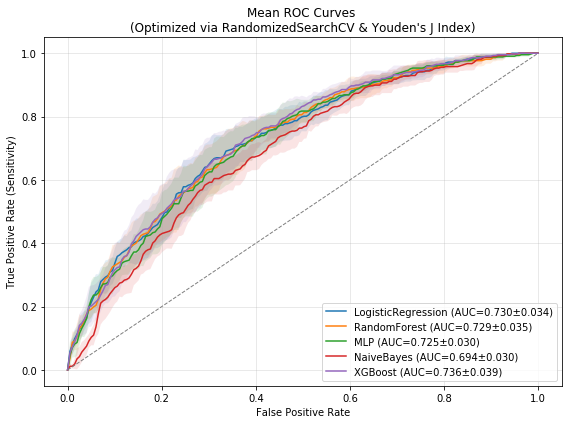

[IterativeImputer] Completing matrix with shape (1647, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.25
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.56
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.95
[IterativeImputer] Ending imputation round 4/10, elapsed time 1.16
[IterativeImputer] Ending imputation round 5/10, elapsed time 1.54
[IterativeImputer] Ending imputation round 6/10, elapsed time 1.77
[IterativeImputer] Ending imputation round 7/10, elapsed time 2.10
[IterativeImputer] Ending imputation round 8/10, elapsed time 2.34
[IterativeImputer] Ending imputation round 9/10, elapsed time 2.68
[IterativeImputer] Ending imputation round 10/10, elapsed time 2.89
[IterativeImputer] Completing matrix with shape (707, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.05
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.09
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.12
[IterativeI

In [5]:
# ==============================================================================
# PHASE 4: RANDOMIZED SEARCH CV, OPTIMIZATION & COMPARATIVE EVALUATION
# ==============================================================================
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

def get_models_and_grids(random_state=RANDOM_STATE):
    scaler = StandardScaler()
    # Note: Using clone(imputer_base) inside pipeline strictly isolates imputation per fold
    models = {
        "LogisticRegression": Pipeline([("imputer", clone(imputer_base)), ("scaler", scaler), ("clf", LogisticRegression(max_iter=1000, random_state=random_state))]),
        "RandomForest": Pipeline([("imputer", clone(imputer_base)), ("clf", RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
        "MLP": Pipeline([("imputer", clone(imputer_base)), ("scaler", scaler), ("clf", MLPClassifier(max_iter=500, early_stopping=True, random_state=random_state))]),
        "NaiveBayes": Pipeline([("imputer", clone(imputer_base)), ("scaler", scaler), ("clf", GaussianNB())]),
    }
    if HAS_XGB:
        models["XGBoost"] = Pipeline([("imputer", clone(imputer_base)), ("clf", XGBClassifier(random_state=random_state, n_jobs=-1, eval_metric="logloss"))])

    param_grids = {
        "LogisticRegression": {"clf__C": [0.01, 0.1, 1.0, 10.0], "clf__penalty": ["l2"]},
        "RandomForest": {"clf__n_estimators": [200, 300, 400], "clf__max_depth": [None, 5, 10, 15], "clf__min_samples_split": [2, 5, 10]},
        "MLP": {"clf__hidden_layer_sizes": [(32,), (64, 32), (128, 64)], "clf__alpha": [1e-4, 1e-3, 1e-2], "clf__learning_rate_init": [0.001, 0.005, 0.01]},
        "NaiveBayes": {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]},
        "XGBoost": {"clf__learning_rate": [0.01, 0.05, 0.1, 0.2], "clf__max_depth": [3, 4, 5, 6], "clf__n_estimators": [100, 300, 500], "clf__subsample": [0.8, 0.9, 1.0], "clf__colsample_bytree": [0.8, 0.9, 1.0]}
    }
    return models, param_grids

base_models, param_grids = get_models_and_grids(RANDOM_STATE)
tuned_models = {}

print("--- Phase 1: RandomizedSearchCV Hyperparameter Tuning ---")
for name, model in base_models.items():
    if name not in param_grids:
        tuned_models[name] = model
        continue
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(estimator=model, param_distributions=param_grids[name], n_iter=15, scoring='roc_auc', cv=3, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
    search.fit(X_train, y_train)
    print(f"  -> Best CV AUC: {search.best_score_:.3f}")
    tuned_models[name] = search.best_estimator_

# CV and Threshold Evaluation
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_results, test_results, roc_curves_cv = {}, {}, {}

print("\n--- Phase 2: Threshold Optimization & Final Evaluation ---")
with tqdm(total=len(tuned_models)*N_SPLITS, desc="Threshold Optimization CV", leave=True) as pbar:
    for name, model in tuned_models.items():
        mean_fpr = np.linspace(0, 1, 200)
        tprs, aucs_roc, aucs_pr = [], [], []
        metrics_per_thr = {thr: {"accuracy": [], "precision": [], "recall": [], "specificity": [], "f1": [], "youden": []} for thr in THRESHOLDS}

        for tr_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

            m = clone(model)
            m.fit(X_tr, y_tr)

            if hasattr(m, "predict_proba"):
                val_score = m.predict_proba(X_val)[:, 1]
            else:
                val_score = m.decision_function(X_val)
                s_min, s_max = np.min(val_score), np.max(val_score)
                if s_max > s_min: val_score = (val_score - s_min) / (s_max - s_min)

            for thr in THRESHOLDS:
                val_pred = (val_score >= thr).astype(int)
                sens = recall_score(y_val, val_pred)
                spec = specificity_score(y_val, val_pred)
                metrics_per_thr[thr]["accuracy"].append(accuracy_score(y_val, val_pred))
                metrics_per_thr[thr]["precision"].append(precision_score(y_val, val_pred, zero_division=0))
                metrics_per_thr[thr]["recall"].append(sens)
                metrics_per_thr[thr]["specificity"].append(spec)
                metrics_per_thr[thr]["f1"].append(f1_score(y_val, val_pred))
                metrics_per_thr[thr]["youden"].append(sens + spec - 1.0)

            aucs_roc.append(roc_auc_score(y_val, val_score))
            aucs_pr.append(average_precision_score(y_val, val_score))
            fpr, tpr, _ = roc_curve(y_val, val_score)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0
            pbar.update(1)

        best_thr, best_val = None, -np.inf
        for thr in THRESHOLDS:
            metric_mean = np.mean(metrics_per_thr[thr][OPTIMIZE_METRIC])
            if metric_mean > best_val:
                best_val, best_thr = metric_mean, thr

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        
        cv_results[name] = {
            "best_threshold": best_thr,
            "accuracy": (float(np.mean(metrics_per_thr[best_thr]["accuracy"])), float(np.std(metrics_per_thr[best_thr]["accuracy"]))),
            "recall_sens": (float(np.mean(metrics_per_thr[best_thr]["recall"])), float(np.std(metrics_per_thr[best_thr]["recall"]))),
            "specificity": (float(np.mean(metrics_per_thr[best_thr]["specificity"])), float(np.std(metrics_per_thr[best_thr]["specificity"]))),
            "f1": (float(np.mean(metrics_per_thr[best_thr]["f1"])), float(np.std(metrics_per_thr[best_thr]["f1"]))),
            "youden": (float(np.mean(metrics_per_thr[best_thr]["youden"])), float(np.std(metrics_per_thr[best_thr]["youden"]))),
            "roc_auc": (float(np.mean(aucs_roc)), float(np.std(aucs_roc))),
        }

        roc_curves_cv[name] = {"mean_fpr": mean_fpr, "mean_tpr": mean_tpr, "std_tpr": np.std(tprs, axis=0), "mean_auc": np.mean(aucs_roc), "std_auc": np.std(aucs_roc)}

        final_m = clone(model)
        final_m.fit(X_train, y_train)

        if hasattr(final_m, "predict_proba"):
            test_score = final_m.predict_proba(X_test)[:, 1]
        else:
            test_score = final_m.decision_function(X_test)
            s_min, s_max = np.min(test_score), np.max(test_score)
            if s_max > s_min: test_score = (test_score - s_min) / (s_max - s_min)

        test_pred = (test_score >= best_thr).astype(int)
        sens_test = recall_score(y_test, test_pred)
        spec_test = specificity_score(y_test, test_pred)

        test_results[name] = {
            "best_threshold": best_thr, "accuracy": accuracy_score(y_test, test_pred),
            "sensitivity": sens_test, "specificity": spec_test, "f1": f1_score(y_test, test_pred),
            "youden": sens_test + spec_test - 1.0, "roc_auc": roc_auc_score(y_test, test_score),
        }

# Print Tables
def fmt(mstd): return f"{mstd[0]:.3f} ± {mstd[1]:.3f}"

cv_rows = []
for name, res in cv_results.items():
    cv_rows.append({"Model": name, "BestThresh": f"{res['best_threshold']:.2f}", "CV Accuracy": fmt(res["accuracy"]), "CV Sensitivity": fmt(res["recall_sens"]), "CV Specificity": fmt(res["specificity"]), "CV Youden J": fmt(res["youden"]), "CV ROC AUC": fmt(res["roc_auc"])})
cv_df = pd.DataFrame(cv_rows).set_index("Model").sort_values("CV ROC AUC", ascending=False)
print("\n--- 1. INTERNAL CROSS-VALIDATION RESULTS (Train Partition Only) ---")
#display(cv_df)

test_rows = []
for name, res in test_results.items():
    test_rows.append({"Model": name, "AppliedThresh": f"{res['best_threshold']:.2f}", "Test Accuracy": f"{res['accuracy']:.3f}", "Test Sensitivity": f"{res['sensitivity']:.3f}", "Test Specificity": f"{res['specificity']:.3f}", "Test Youden J": f"{res['youden']:.3f}", "Test ROC AUC": f"{res['roc_auc']:.3f}"})
test_df = pd.DataFrame(test_rows).set_index("Model").sort_values("Test ROC AUC", ascending=False)
print("\n--- 2. LOCKED TEST SET VALIDATION RESULTS (Unbiased Evaluation) ---")
#display(test_df)

# Plot Mean ROC Curves
plt.figure(figsize=(8,6))
for name, rb in roc_curves_cv.items():
    fpr, tpr, std_tpr = rb["mean_fpr"], rb["mean_tpr"], rb["std_tpr"]
    auc, std_auc = rb["mean_auc"], rb["std_auc"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f}±{std_auc:.3f})")
    plt.fill_between(fpr, np.maximum(tpr - std_tpr, 0), np.minimum(tpr + std_tpr, 1), alpha=0.12)

plt.plot([0,1], [0,1], '--', color="grey", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Mean ROC Curves \n(Optimized via RandomizedSearchCV & Youden's J Index)")
plt.legend(loc="lower right")
plt.grid(alpha=0.35)
plt.tight_layout()
plt.savefig("mean_ROC_curve_tuned_unbalanced.jpg", dpi=400, format="jpg", bbox_inches="tight")
plt.show()

# Export Main LR parameters for downstream cells
main_model = tuned_models["LogisticRegression"]
main_model.fit(X_train, y_train)
y_prob_main = main_model.predict_proba(X_test)[:, 1]
best_thr = cv_results["LogisticRegression"]["best_threshold"]

,BestThresh,CV Accuracy,CV Sensitivity,CV Specificity,CV Youden J,CV ROC AUC
Model,,,,,,
XGBoost,0.30,0.677 ± 0.028,0.668 ± 0.071,0.680 ± 0.020,0.348 ± 0.082,0.736 ± 0.039
LogisticRegression,0.26,0.685 ± 0.027,0.672 ± 0.068,0.689 ± 0.022,0.362 ± 0.077,0.730 ± 0.034
RandomForest,0.26,0.645 ± 0.019,0.726 ± 0.050,0.616 ± 0.012,0.342 ± 0.057,0.729 ± 0.035
MLP,0.20,0.639 ± 0.033,0.738 ± 0.048,0.604 ± 0.036,0.342 ± 0.068,0.725 ± 0.030
NaiveBayes,0.12,0.673 ± 0.017,0.588 ± 0.045,0.702 ± 0.020,0.290 ± 0.045,0.694 ± 0.030


,AppliedThresh,Test Accuracy,Test Sensitivity,Test Specificity,Test Youden J,Test ROC AUC
Model,,,,,,
XGBoost,0.30,0.645,0.667,0.637,0.304,0.716
RandomForest,0.26,0.621,0.765,0.571,0.336,0.713
LogisticRegression,0.26,0.659,0.689,0.649,0.337,0.710
MLP,0.20,0.573,0.781,0.500,0.281,0.702
NaiveBayes,0.12,0.636,0.552,0.666,0.218,0.673


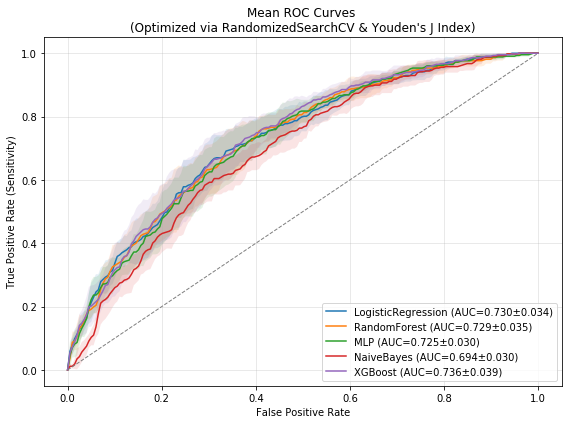

In [6]:
display(cv_df)
display(test_df)

plt.figure(figsize=(8,6))
for name, rb in roc_curves_cv.items():
    fpr, tpr, std_tpr = rb["mean_fpr"], rb["mean_tpr"], rb["std_tpr"]
    auc, std_auc = rb["mean_auc"], rb["std_auc"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f}±{std_auc:.3f})")
    plt.fill_between(fpr, np.maximum(tpr - std_tpr, 0), np.minimum(tpr + std_tpr, 1), alpha=0.12)

plt.plot([0,1], [0,1], '--', color="grey", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Mean ROC Curves \n(Optimized via RandomizedSearchCV & Youden's J Index)")
plt.legend(loc="lower right")
plt.grid(alpha=0.35)
plt.tight_layout()
plt.savefig("mean_ROC_curve_tuned_unbalanced.jpg", dpi=400, format="jpg", bbox_inches="tight")
plt.show()

In [7]:
# ==============================================================================
# PHASE 5: BOOTSTRAPPED CIs & CALIBRATION 
# ==============================================================================
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

def get_metrics(y_t, y_p, thr):
    pred = (y_p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_t, pred).ravel()
    
    # Calibration stats inside bootstrap
    epsilon = 1e-15
    y_p_clipped = np.clip(y_p, epsilon, 1 - epsilon)
    logit_p = np.log(y_p_clipped / (1 - y_p_clipped)).reshape(-1, 1)
    
    calib_model = LogisticRegression(penalty='none', solver='lbfgs')
    calib_model.fit(logit_p, y_t)
    
    return {
        'auc': roc_auc_score(y_t, y_p),
        'sens': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'spec': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'ppv': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'npv': tn / (tn + fn) if (tn + fn) > 0 else 0,
        'acc': (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0,
        'calib_intercept': calib_model.intercept_[0],
        'calib_slope': calib_model.coef_[0][0]
    }

boot_results = {'auc': [], 'sens': [], 'spec': [], 'ppv': [], 'npv': [], 'acc': [], 'calib_intercept': [], 'calib_slope': []}
np.random.seed(RANDOM_STATE)

for i in tqdm(range(1000), desc="Bootstrapping CIs"):
    indices = resample(np.arange(len(y_test)), replace=True)
    if len(np.unique(y_test.iloc[indices])) < 2: continue
    m = get_metrics(y_test.iloc[indices], y_prob_main[indices], best_thr)
    for k in boot_results: boot_results[k].append(m[k])

print(f"\n--- Bootstrapped 95% CIs for Main Model (Threshold = {best_thr:.2f}) ---")
for metric in boot_results:
    mean_val = np.mean(boot_results[metric])
    ci_lower = np.percentile(boot_results[metric], 2.5)
    ci_upper = np.percentile(boot_results[metric], 97.5)
    
    if metric in ['calib_intercept', 'calib_slope']:
        ideal = 0 if metric == 'calib_intercept' else 1
        print(f"{metric.upper():16s} : {mean_val:.3f} (95% CI: {ci_lower:.3f} to {ci_upper:.3f}) | Ideal = {ideal}")
    else:
        print(f"{metric.upper():16s} : {mean_val:.3f} (95% CI: {ci_lower:.3f} to {ci_upper:.3f})")

print(f"BRIER SCORE      : {brier_score_loss(y_test, y_prob_main):.3f}")

Bootstrapping CIs:   0%|          | 0/1000 [00:00<?, ?it/s]


--- Bootstrapped 95% CIs for Main Model (Threshold = 0.26) ---
AUC              : 0.710 (95% CI: 0.671 to 0.752)
SENS             : 0.660 (95% CI: 0.592 to 0.727)
SPEC             : 0.648 (95% CI: 0.608 to 0.689)
PPV              : 0.395 (95% CI: 0.345 to 0.446)
NPV              : 0.846 (95% CI: 0.810 to 0.881)
ACC              : 0.651 (95% CI: 0.618 to 0.685)
CALIB_INTERCEPT  : -0.170 (95% CI: -0.409 to 0.095) | Ideal = 0
CALIB_SLOPE      : 0.865 (95% CI: 0.672 to 1.089) | Ideal = 1
BRIER SCORE      : 0.173


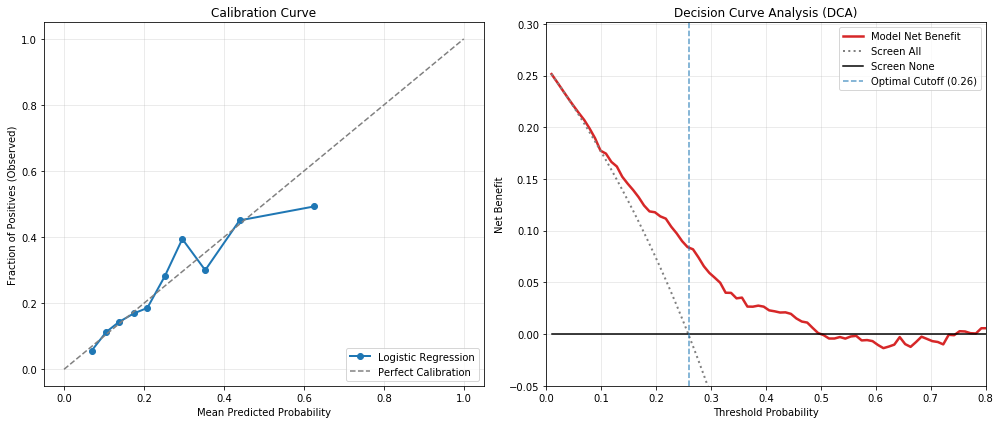

Selected C value: 0.1


In [8]:
# ==============================================================================
# PHASE 6: CALIBRATION CURVE & DECISION CURVE ANALYSIS (DCA) PLOTTING
# ==============================================================================
def calculate_net_benefit(y_true, y_prob, pt_arr):
    net_benefit = []
    N = len(y_true)
    for pt in pt_arr:
        if pt == 1.0:
            net_benefit.append(0)
            continue
        preds = (y_prob >= pt).astype(int)
        tp_count = np.sum((preds == 1) & (y_true == 1))
        fp_count = np.sum((preds == 1) & (y_true == 0))
        nb = (tp_count / N) - (fp_count / N) * (pt / (1 - pt))
        net_benefit.append(nb)
    return np.array(net_benefit)

pt_arr = np.linspace(0.01, 0.99, 100)
nb_model = calculate_net_benefit(y_test.values, y_prob_main, pt_arr)
overall_prevalence = np.mean(y_test.values)
nb_all = overall_prevalence - (1 - overall_prevalence) * (pt_arr / (1 - pt_arr))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_prob_main, n_bins=10, strategy='quantile')
axes[0].plot(prob_pred, prob_true, marker='o', linewidth=2, color='tab:blue', label='Logistic Regression')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Fraction of Positives (Observed)")
axes[0].set_title("Calibration Curve")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# 2. Decision Curve Analysis (DCA)
axes[1].plot(pt_arr, nb_model, color='tab:red', linewidth=2.5, label='Model Net Benefit')
axes[1].plot(pt_arr, nb_all, color='gray', linestyle=':', linewidth=2, label='Screen All')
axes[1].plot(pt_arr, np.zeros_like(pt_arr), color='black', linewidth=1.5, label='Screen None')
axes[1].axvline(x=best_thr, color='tab:blue', linestyle='--', alpha=0.7, label=f'Optimal Cutoff ({best_thr:.2f})')
axes[1].set_ylim([-0.05, max(np.max(nb_model), np.max(nb_all)) + 0.05])
axes[1].set_xlim([0.0, 0.8]) 
axes[1].set_xlabel("Threshold Probability")
axes[1].set_ylabel("Net Benefit")
axes[1].set_title("Decision Curve Analysis (DCA)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Calibration_DCA.jpg", dpi=400, bbox_inches="tight")
plt.show()
print(f"Selected C value: {tuned_models['LogisticRegression'].named_steps['clf'].C}")

In [14]:
# ---------------------------------------------------------
# A. Clinical Odds Ratios (Crude & Multi Pooled via Rubin's Rules)
# ---------------------------------------------------------
print("="*85)
print("   CLINICAL INCREMENT ODDS RATIOS (POOLED ACROSS m=10 IMPUTATIONS) - Table 2")
print("="*85)

clinical_increments = {
    'age_m': 5.0, 'BMI (kg/m^2)': 5.0, 'alt_1': 10.0, 'ast_1': 10.0,
    'tg_1': 10.0, 'hdl_1': 10.0, 'ldl_1': 10.0, 'sbp_mean': 10.0, 'dbp_mean': 10.0
}
binary_cols = ['sex', 'm_hbsab_1', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1', 'm_t2dm_1']
m_imputations = 10

# Lists for Multivariable model
multi_coefs = []
multi_vars = []

# Dictionaries for Crude models (MODIFIED: X_train changed to X)
crude_coefs = {col: [] for col in X.columns}
crude_vars = {col: [] for col in X.columns}

# MODIFIED: Running imputation on the FULL dataset (X) instead of X_train
for i in tqdm(range(m_imputations), desc="Imputing & Fitting Models on Full Cohort"):
    imp = IterativeImputer(max_iter=10, sample_posterior=True, random_state=RANDOM_STATE + i, initial_strategy='mean')
    
    # MODIFIED: X_train changed to X
    X_imp_m = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
    
    # Binarize categorical columns for the current imputed dataset
    for col in binary_cols:
        X_imp_m[col] = np.where(X_imp_m[col] > 0.5, 1.0, 0.0)
    
    X_clin = X_imp_m.copy()
    for col, inc in clinical_increments.items():
        if col in X_clin.columns: 
            X_clin[col] = X_clin[col] / inc
            
    X_mat = sm.add_constant(X_clin.apply(pd.to_numeric).astype(float))
    
    # MODIFIED: y_train changed to y (Full Cohort)
    y_sm = y.values.astype(float)
    
    # --- 1. Fit Multivariable Model ---
    try:
        model_sm = sm.Logit(y_sm, X_mat).fit(disp=0, method='bfgs')
        multi_coefs.append(model_sm.params)
        multi_vars.append(model_sm.bse ** 2)
    except:
        pass
        
    # --- 2. Fit Crude (Univariable) Models ---
    for col in X_clin.columns:
        X_univ = sm.add_constant(X_clin[[col]].apply(pd.to_numeric).astype(float))
        try:
            crude_model = sm.Logit(y_sm, X_univ).fit(disp=0)
            crude_coefs[col].append(crude_model.params[col])
            crude_vars[col].append(crude_model.bse[col] ** 2)
        except:
            pass

# --- Apply Rubin's Rules ---
def apply_rubin(coef_list, var_list):
    Q_bar = np.mean(coef_list, axis=0)
    U_bar = np.mean(var_list, axis=0)
    B = np.var(coef_list, axis=0, ddof=1)
    T = U_bar + (1 + 1/m_imputations) * B
    SE = np.sqrt(T)
    
    OR = np.exp(Q_bar)
    CI_L = np.exp(Q_bar - 1.96 * SE)
    CI_U = np.exp(Q_bar + 1.96 * SE)
    pval = 2 * (1 - norm.cdf(np.abs(Q_bar / SE)))
    return OR, CI_L, CI_U, pval

# Pool Multivariable Results
multi_Q_bar = pd.DataFrame(multi_coefs).mean(axis=0) 
multi_U_bar = pd.DataFrame(multi_vars).mean(axis=0)  
multi_B = pd.DataFrame(multi_coefs).var(axis=0, ddof=1) 
multi_T = multi_U_bar + (1 + 1/m_imputations) * multi_B 
multi_SE_pooled = np.sqrt(multi_T)

multi_df = pd.DataFrame({
    "Pooled Multi OR": np.exp(multi_Q_bar),
    "Multi Lower 95% CI": np.exp(multi_Q_bar - 1.96 * multi_SE_pooled),
    "Multi Upper 95% CI": np.exp(multi_Q_bar + 1.96 * multi_SE_pooled),
    "Multi p-value": 2 * (1 - norm.cdf(np.abs(multi_Q_bar / multi_SE_pooled)))
}).drop(index="const", errors="ignore")

# Pool Crude Results
crude_results_list = []

# MODIFIED: X_train changed to X
for col in X.columns:
    if len(crude_coefs[col]) > 0:
        c_or, c_cil, c_ciu, c_pval = apply_rubin(crude_coefs[col], crude_vars[col])
        crude_results_list.append({
            "Feature": col,
            "Pooled Crude OR": c_or,
            "Crude Lower 95% CI": c_cil,
            "Crude Upper 95% CI": c_ciu,
            "Crude p-value": c_pval
        })
crude_df = pd.DataFrame(crude_results_list).set_index("Feature")

# Combine Crude and Multi into Final Table 2
final_coef_table = crude_df.join(multi_df).round(3)
display(final_coef_table)


# ---------------------------------------------------------
# B. Clinical Utility Metrics Across Plausible Thresholds
# ---------------------------------------------------------
print("\n" + "="*85)
print("   CLINICAL UTILITY METRICS ACROSS PLAUSIBLE RISK THRESHOLDS (Test Set) - Supp Table 4")
print("="*85)
eval_thresholds = [0.10, 0.15, 0.20, 0.22, 0.25, 0.26, 0.30, 0.40, 0.50]
utility_rows = []

# Note: This section correctly evaluates on the Test Set (y_test) to avoid data leakage
for thr in eval_thresholds:
    preds = (y_prob_main >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    
    utility_rows.append({
        "Threshold": f"> {thr*100:.0f}% Risk", 
        "Sensitivity (%)": sens * 100,
        "Specificity (%)": spec * 100, 
        "PPV (%)": ppv * 100, 
        "NPV (%)": npv * 100,
        "False Positives": fp, 
        "False Negatives": fn
    })

display(pd.DataFrame(utility_rows).set_index("Threshold").round(1))

   CLINICAL INCREMENT ODDS RATIOS (POOLED ACROSS m=10 IMPUTATIONS) - Table 2


Imputing & Fitting Models on Full Cohort:   0%|          | 0/10 [00:00<?, ?it/s]

,Pooled Crude OR,Crude Lower 95% CI,Crude Upper 95% CI,Crude p-value,Pooled Multi OR,Multi Lower 95% CI,Multi Upper 95% CI,Multi p-value
Feature,,,,,,,,
alt_1,1.210,1.129,1.296,0.000,1.275,1.145,1.420,0.000
ast_1,1.054,0.950,1.170,0.321,0.772,0.641,0.929,0.006
tg_1,1.053,1.041,1.066,0.000,1.026,1.012,1.041,0.000
hdl_1,0.873,0.819,0.930,0.000,0.960,0.889,1.037,0.301
ldl_1,1.051,1.023,1.079,0.000,1.011,0.980,1.042,0.500
sex,0.831,0.690,1.000,0.051,1.374,1.066,1.771,0.014
age_m,1.007,0.977,1.038,0.640,0.923,0.886,0.962,0.000
m_hbsab_1,0.763,0.620,0.939,0.011,0.823,0.657,1.031,0.091
m_smoke_1,0.806,0.621,1.046,0.105,0.859,0.628,1.176,0.343



   CLINICAL UTILITY METRICS ACROSS PLAUSIBLE RISK THRESHOLDS (Test Set) - Supp Table 4


,Sensitivity (%),Specificity (%),PPV (%),NPV (%),False Positives,False Negatives
Threshold,,,,,,
> 10% Risk,95.1,16.4,28.4,90.5,438,9
> 15% Risk,89.1,34.7,32.3,90.1,342,20
> 20% Risk,80.9,50.8,36.5,88.4,258,35
> 22% Risk,78.1,56.9,38.8,88.2,226,40
> 25% Risk,69.9,62.8,39.6,85.7,195,55
> 26% Risk,66.1,64.7,39.5,84.5,185,62
> 30% Risk,54.6,73.7,42.0,82.3,138,83
> 40% Risk,34.4,87.0,48.1,79.2,68,120
> 50% Risk,19.1,93.3,50.0,76.8,35,148


In [10]:
# ==============================================================================
# PHASE 9: SENSITIVITY ANALYSIS FOR AGE (Reviewer Comment 7)
# Evaluating Functional Form of Age (Categorical vs. Non-linear)
# ==============================================================================
print("="*85)
print("   SENSITIVITY ANALYSIS: EVALUATING FUNCTIONAL FORM OF AGE")
print("="*85)

# We need the increments and binary columns from Phase 7
clinical_increments = {
    'age_m': 5.0, 'BMI (kg/m^2)': 5.0, 'alt_1': 10.0, 'ast_1': 10.0,
    'tg_1': 10.0, 'hdl_1': 10.0, 'ldl_1': 10.0, 'sbp_mean': 10.0, 'dbp_mean': 10.0
}
binary_cols = ['sex', 'm_hbsab_1', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1', 'm_t2dm_1']

m_imputations = 10
coefs_cat, vars_cat = [], []
coefs_nonlin, vars_nonlin = [], []

print(f"Running Multiple Imputation (m={m_imputations}) for Age Sensitivity Models...")
for i in tqdm(range(m_imputations), desc="Imputing & Fitting"):
    imp = IterativeImputer(max_iter=10, sample_posterior=True, random_state=RANDOM_STATE + i, initial_strategy='mean')
    X_imp_m = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns)
    
    # Binarize categoricals
    for col in binary_cols:
        X_imp_m[col] = np.where(X_imp_m[col] > 0.5, 1.0, 0.0)
        
    X_clin = X_imp_m.copy()
    
    # --- Create Age Strata (Ref: <40 years) ---
    X_clin['age_40_to_55'] = np.where((X_clin['age_m'] >= 40) & (X_clin['age_m'] <= 55), 1.0, 0.0)
    X_clin['age_gt_55'] = np.where((X_clin['age_m'] > 55), 1.0, 0.0)
    
    # --- Create Non-linear Age term (Age squared, scaled to prevent overflow) ---
    X_clin['age_m_squared'] = (X_clin['age_m'] / 10.0) ** 2  
    
    # Scale clinical increments
    for col, inc in clinical_increments.items():
        if col in X_clin.columns: X_clin[col] = X_clin[col] / inc
            
    y_sm = y_train.values.astype(float)
    
    # Model A: Age as Categorical
    cols_cat = [c for c in X_clin.columns if c not in ['age_m', 'age_m_squared']]
    X_mat_cat = sm.add_constant(X_clin[cols_cat].apply(pd.to_numeric).astype(float))
    
    # Model B: Non-linear Age
    cols_nonlin = [c for c in X_clin.columns if c not in ['age_40_to_55', 'age_gt_55']]
    X_mat_nonlin = sm.add_constant(X_clin[cols_nonlin].apply(pd.to_numeric).astype(float))
    
    try:
        mod_cat = sm.Logit(y_sm, X_mat_cat).fit(disp=0, method='bfgs')
        coefs_cat.append(mod_cat.params)
        vars_cat.append(mod_cat.bse ** 2)
        
        mod_nonlin = sm.Logit(y_sm, X_mat_nonlin).fit(disp=0, method='bfgs')
        coefs_nonlin.append(mod_nonlin.params)
        vars_nonlin.append(mod_nonlin.bse ** 2)
    except:
        continue

def apply_rubins_rules(coefs, variances):
    Q_bar = pd.DataFrame(coefs).mean(axis=0)
    U_bar = pd.DataFrame(variances).mean(axis=0)
    B = pd.DataFrame(coefs).var(axis=0, ddof=1)
    T = U_bar + (1 + 1/m_imputations) * B
    SE_pooled = np.sqrt(T)
    
    df = pd.DataFrame({
        "Pooled OR": np.exp(Q_bar),
        "Lower 95% CI": np.exp(Q_bar - 1.96 * SE_pooled),
        "Upper 95% CI": np.exp(Q_bar + 1.96 * SE_pooled),
        "p-value": 2 * (1 - norm.cdf(np.abs(Q_bar / SE_pooled)))
    }).drop(index="const", errors="ignore").round(3)
    return df

print("\n--- MODEL A: Age as Categorical Strata (Reference: <40 years) ---")
df_cat_res = apply_rubins_rules(coefs_cat, vars_cat)
display(df_cat_res.loc[['age_40_to_55', 'age_gt_55']])

print("\n--- MODEL B: Continuous Age with Non-Linear Term (Age + Age^2) ---")
df_nonlin_res = apply_rubins_rules(coefs_nonlin, vars_nonlin)
display(df_nonlin_res.loc[['age_m', 'age_m_squared']])

   SENSITIVITY ANALYSIS: EVALUATING FUNCTIONAL FORM OF AGE
Running Multiple Imputation (m=10) for Age Sensitivity Models...


Imputing & Fitting:   0%|          | 0/10 [00:00<?, ?it/s]


--- MODEL A: Age as Categorical Strata (Reference: <40 years) ---


,Pooled OR,Lower 95% CI,Upper 95% CI,p-value
age_40_to_55,0.872,0.655,1.161,0.347
age_gt_55,0.473,0.323,0.692,0.000



--- MODEL B: Continuous Age with Non-Linear Term (Age + Age^2) ---


,Pooled OR,Lower 95% CI,Upper 95% CI,p-value
age_m,1.033,0.787,1.356,0.816
age_m_squared,0.975,0.918,1.034,0.397


In [11]:
# ==============================================================================
# Extracting Best Hyperparameters for Logistic Regression
# ==============================================================================
lr_pipeline = tuned_models["LogisticRegression"]
best_c = lr_pipeline.named_steps["clf"].C
best_penalty = lr_pipeline.named_steps["clf"].penalty

print("\n--- Final Tuned Hyperparameters for Predictive Logistic Regression ---")
print(f"Selected Regularization Parameter (C): {best_c}")
print(f"Selected Penalty: {best_penalty}")


--- Final Tuned Hyperparameters for Predictive Logistic Regression ---
Selected Regularization Parameter (C): 0.1
Selected Penalty: l2


--- Generating SHAP values on strictly Imputed Dataset ---
[IterativeImputer] Completing matrix with shape (2354, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.12
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.30
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.46
[IterativeImputer] Ending imputation round 4/10, elapsed time 0.68
[IterativeImputer] Ending imputation round 5/10, elapsed time 0.81
[IterativeImputer] Ending imputation round 6/10, elapsed time 0.99
[IterativeImputer] Ending imputation round 7/10, elapsed time 1.24
[IterativeImputer] Ending imputation round 8/10, elapsed time 1.51
[IterativeImputer] Ending imputation round 9/10, elapsed time 1.69
[IterativeImputer] Ending imputation round 10/10, elapsed time 1.91


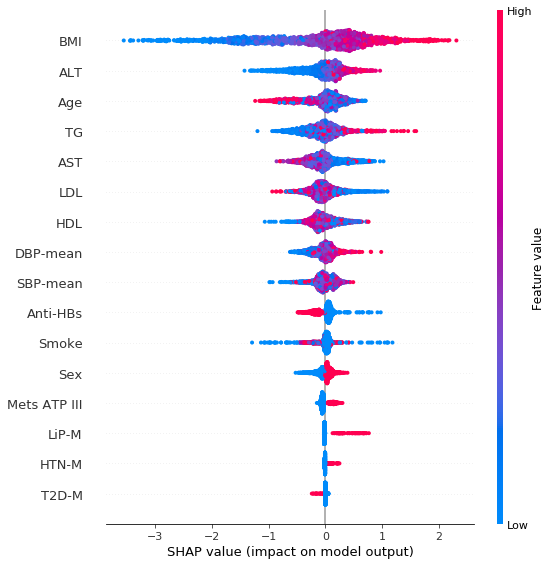

In [12]:
# ==============================================================================
# PHASE 8: XGBoost SHAP SUMMARY PLOT (CORRECTED FOR DATA LEAKAGE)
# ==============================================================================
print("--- Generating SHAP values on strictly Imputed Dataset ---")

# Transform the entire X using the imputer fitted ONLY on X_train to prevent data leakage
X_shap_imp = pd.DataFrame(imputer_base.transform(X), columns=X.columns, index=X.index)

# Fit XGBoost on the properly imputed dataset (Natural Prevalence)
xgb_shap = XGBClassifier(
    n_estimators=600, learning_rate=0.05, max_depth=4, subsample=0.9,
    colsample_bytree=0.9, reg_lambda=3.0, random_state=RANDOM_STATE,
    n_jobs=-1, eval_metric="logloss"
)
xgb_shap.fit(X_shap_imp, y)

# Sample rows for SHAP speed
MAX_ROWS = 2000
if len(X_shap_imp) > MAX_ROWS:
    rng = np.random.default_rng(RANDOM_STATE)
    samp_idx = rng.choice(X_shap_imp.index, size=MAX_ROWS, replace=False)
    X_for_shap = X_shap_imp.loc[samp_idx]
else:
    X_for_shap = X_shap_imp.copy()

# Rename for display
name_map = {
    "BMI (kg/m^2)": "BMI", "m_sld_1": "Baseline SLD", "alt_1": "ALT",
    "age_m": "Age", "ast_1": "AST", "tg_1": "TG", "sex": "Sex",
    "m_hbsab_1": "Anti-HBs", "dbp_mean": "DBP-mean", "m_fbs_1": "FBS",
    "m_smoke_1": "Smoke", "m_lipm_1": "LiP-M", "hdl_1": "HDL",
    "m_htnm_1": "HTN-M", "sbp_mean": "SBP-mean", "m_t2dm_1": "T2D-M",
    "ldl_1": "LDL", "m_metsatp3_1": "Mets ATP III"
}
X_disp = X_for_shap.rename(columns=name_map)

# SHAP Explainer
explainer = shap.TreeExplainer(xgb_shap)

MM_TO_IN = 1 / 25.4
plt.figure(figsize=(107 * MM_TO_IN, 80 * MM_TO_IN))
plt.rcParams.update({"font.size": 8, "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 8})

try:
    explanation = explainer(X_for_shap)
    shap.summary_plot(explanation.values, features=X_disp, feature_names=X_disp.columns, show=False)
except Exception:
    shap_values = explainer.shap_values(X_for_shap)
    shap.summary_plot(shap_values, features=X_disp, feature_names=X_disp.columns, show=False)

plt.tight_layout()
plt.savefig("shap_summary_107mm_300dpi.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# ==============================================================================
# PHASE 10: EXTRACTING FINAL HYPERPARAMETERS FOR LOGISTIC REGRESSION
# ==============================================================================

lr_pipeline = tuned_models["LogisticRegression"]
lr_clf = lr_pipeline.named_steps["clf"]
best_c = lr_clf.C
best_penalty = lr_clf.penalty
max_iter = lr_clf.max_iter

print("="*85)
print("   FINAL HYPERPARAMETERS FOR PREDICTIVE LOGISTIC REGRESSION MODEL")
print("="*85)
print(f"Selected Regularization Parameter (C) : {best_c}")
print(f"Selected Penalty type                 : {best_penalty}")
print(f"Maximum Iterations (max_iter)         : {max_iter}")
print("="*85)

# ==============================================================================
# EXPORTING SUPPLEMENTARY TABLE 5 
# Absolute Risk Calculation Formula (Logistic Regression Coefficients)
# ==============================================================================
import pandas as pd

print("="*85)
print("   GENERATING SUPPLEMENTARY TABLE 5...")
print("="*85)

# 1. Recalculate unscaled coefficients from the main predictive model
scaler = main_model.named_steps['scaler']
clf = main_model.named_steps['clf']

coef_scaled = clf.coef_[0]
intercept_scaled = clf.intercept_[0]
means = scaler.mean_
scales = scaler.scale_

coef_raw = coef_scaled / scales
intercept_raw = intercept_scaled - np.sum((coef_scaled * means) / scales)

# 2. Dictionary mapping exact feature names to clinical descriptions and coding instructions
desc_dict = {
    'alt_1': ('ALT', 'Continuous (U/L)'),
    'ast_1': ('AST', 'Continuous (U/L)'),
    'tg_1': ('Triglycerides', 'Continuous (mg/dL)'),
    'hdl_1': ('HDL Cholesterol', 'Continuous (mg/dL)'),
    'ldl_1': ('LDL Cholesterol', 'Continuous (mg/dL)'),
    'sex': ('Sex', '1 = Male, 0 = Female'),
    'age_m': ('Age', 'Continuous (years)'),
    'm_hbsab_1': ('HBsAb Status', '1 = Positive, 0 = Negative'),
    'm_smoke_1': ('Current Smoker', '1 = Yes, 0 = No'),
    'm_metsatp3_1': ('Metabolic Syndrome (ATP III)', '1 = Yes, 0 = No'),
    'm_lipm_1': ('Dyslipidemia', '1 = Yes, 0 = No'),
    'm_htnm_1': ('Hypertension', '1 = Yes (Clinical diagnosis OR use of antihypertensive medication), 0 = No'),
    'm_t2dm_1': ('Type 2 Diabetes', '1 = Yes (Clinical diagnosis OR use of anti-diabetic medication), 0 = No'),
    'sbp_mean': ('Systolic Blood Pressure', 'Continuous (mmHg)'),
    'dbp_mean': ('Diastolic Blood Pressure', 'Continuous (mmHg)'),
    'BMI (kg/m^2)': ('Body Mass Index', 'Continuous (kg/m²)')
}

# 3. Build the table rows
rows = []

# Add Intercept as the first row
rows.append({
    "Variable Name in Equation": "Intercept (β0)",
    "Clinical Predictor": "Base Intercept",
    "Coding Instructions / Units": "-",
    "Coefficient (β)": round(intercept_raw, 4)
})

# Add all features
for feature_name, coef in zip(X_test_imp.columns, coef_raw):
    predictor, coding = desc_dict.get(feature_name, (feature_name, "-"))
    rows.append({
        "Variable Name in Equation": feature_name,
        "Clinical Predictor": predictor,
        "Coding Instructions / Units": coding,
        "Coefficient (β)": round(coef, 4)
    })
    
# 4. Create DataFrame and Display
df_supp5 = pd.DataFrame(rows)

# Add information about chosen C and penalty
best_c = clf.C
best_penalty = clf.penalty
print(f"Model Specifications: L2-penalized Logistic Regression (optimized C = {best_c}).")
print("Coefficients are unscaled to allow for direct calculation using raw clinical values.\n")

display(df_supp5)

   FINAL HYPERPARAMETERS FOR PREDICTIVE LOGISTIC REGRESSION MODEL
Selected Regularization Parameter (C) : 0.1
Selected Penalty type                 : l2
Maximum Iterations (max_iter)         : 1000
   GENERATING SUPPLEMENTARY TABLE 5...
Model Specifications: L2-penalized Logistic Regression (optimized C = 0.1).
Coefficients are unscaled to allow for direct calculation using raw clinical values.



,Variable Name in Equation,Clinical Predictor,Coding Instructions / Units,Coefficient (β)
0,Intercept (β0),Base Intercept,-,-6.2329
1,alt_1,ALT,Continuous (U/L),0.0141
2,ast_1,AST,Continuous (U/L),-0.0072
3,tg_1,Triglycerides,Continuous (mg/dL),0.0030
4,hdl_1,HDL Cholesterol,Continuous (mg/dL),-0.0017
5,ldl_1,LDL Cholesterol,Continuous (mg/dL),0.0022
6,sex,Sex,"1 = Male, 0 = Female",0.2648
7,age_m,Age,Continuous (years),-0.0129
8,m_hbsab_1,HBsAb Status,"1 = Positive, 0 = Negative",-0.3044
9,m_smoke_1,Current Smoker,"1 = Yes, 0 = No",-0.0290
